##Business Understanding
Customer churn is a big problem for the telecommunication industry, as it is more cost-effective to keep current customers than to acquire new ones.

The goal of this project is to analyze customer behavior based on the Telco Customer Churn dataset to determine the main factors that influence customer churn.

This will help telecommunication companies understand customer behavior, increase customer satisfaction, and prevent revenue loss.

The goal of this data analysis is to explore the data, derive meaningful insights, and create a model to help detect potential customer churn.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd



Mounted at /content/drive


In [2]:
url='/content/drive/MyDrive/dataset/TelcoCustomerChurn.csv'
df=pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##Data understanding

in this section, we explore the dataset to understand its structure,features,and target variable.

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


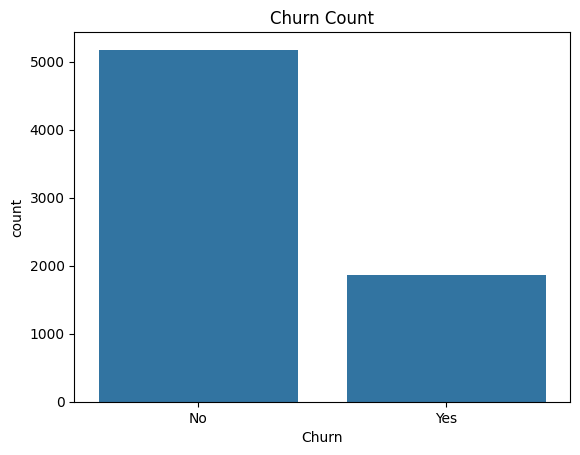

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Churn',data=df)
plt.title('Churn Count')
plt.show()

##Observations

- The dataset contains a sufficient number of customer records for analysis.

- The dataset includes both numerical and categorical features and Some features may require data type conversion before analysis.

- The target variable is Churn, which indicates whether a customer left the service and it is appears to be slightly imbalanced, with more customers staying than leaving

- Certain numerical features vary in scale and may need normalization.

##Data Cleaning

in this section, we prepare the dataset by handling missing values,correcting data types, and ensuring data consistency

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df.dropna(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.drop('customerID',axis=1,inplace=True)

##Cleaning Summary

- Converted TotalCharges to numeric format.
- Removed missing values.
- Checked for duplicate records.
- Dropped irrelevant identifier column (customerID).

##Exploratory Data Analysis (EDA)

This section explores the relationship between customer characteristics and churn behavior to identify potential patterns.

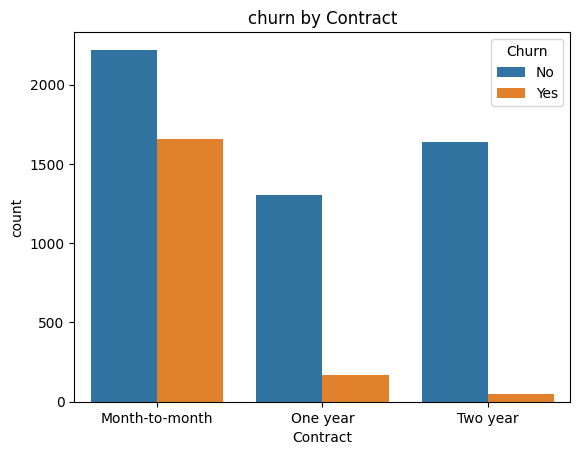

In [15]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title('churn by Contract')
plt.show()

- Customers with month-to-month contracts tend to churn more than those with long-term contracts.

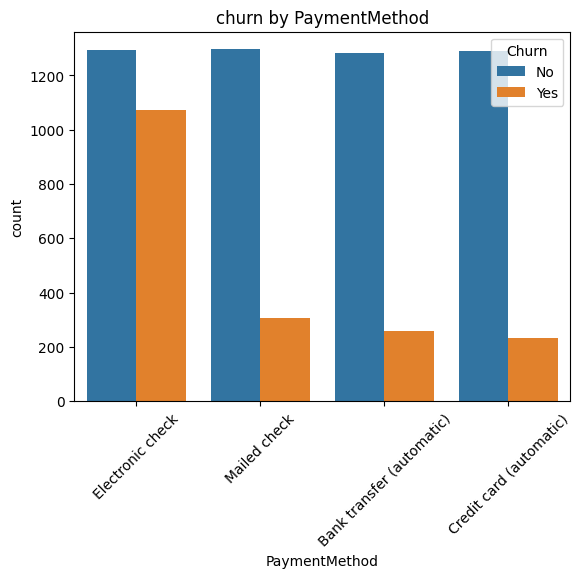

In [16]:
sns.countplot(x='PaymentMethod',hue='Churn',data=df)
plt.xticks(rotation=45)
plt.title('churn by PaymentMethod')
plt.show()

- Customers using electronic check show higher churn behavior.

- Customers with shorter tenure are more likely to churn.

- Customers with higher monthly charges tend to churn more.

##EDA Summary

- Month-to-month contracts are associated with higher churn.
- Electronic check users show increased churn.
- Customers with shorter tenure are more likely to leave.
- Higher monthly charges may contribute to churn.

##Feature Investigation


In this section, we examine specific variables that may influence customer churn in order to determine whether they should be transformed into engineered features.

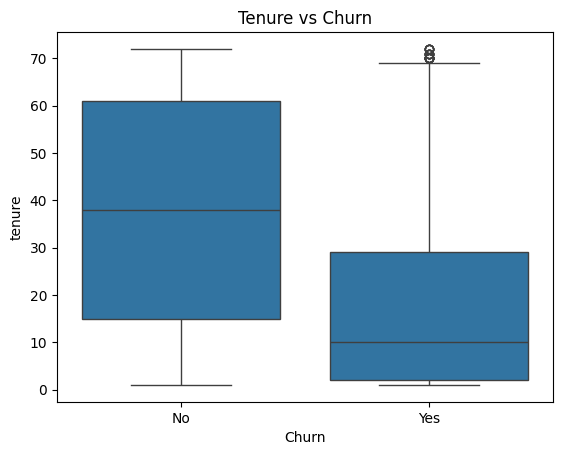

In [17]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

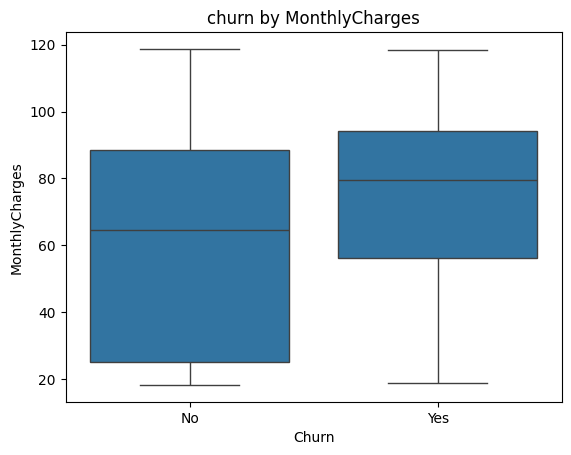

In [18]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title('churn by MonthlyCharges')
plt.show()

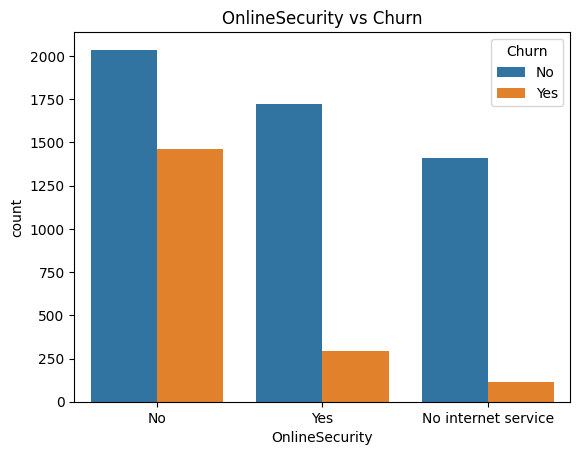

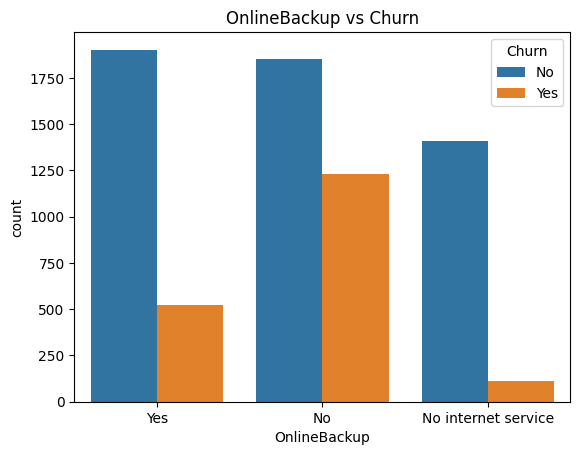

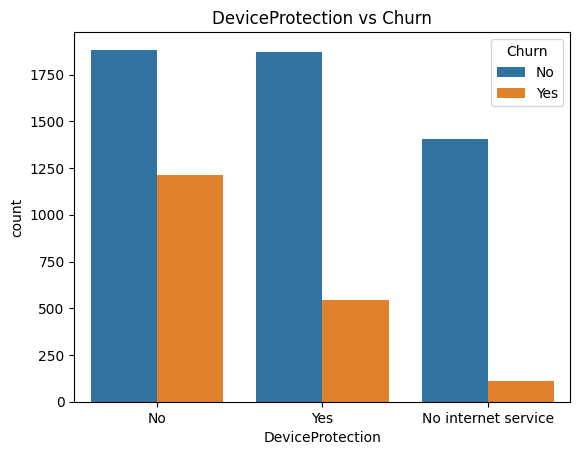

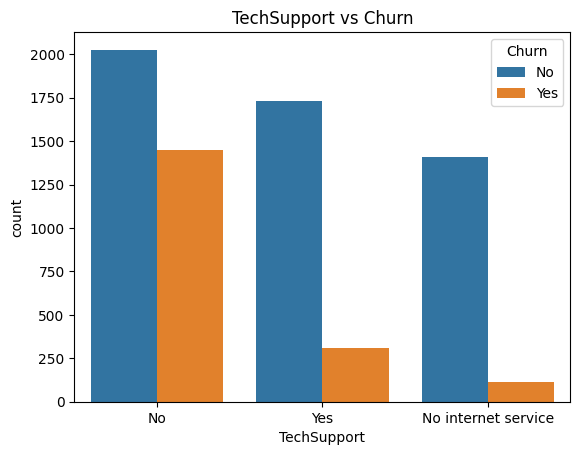

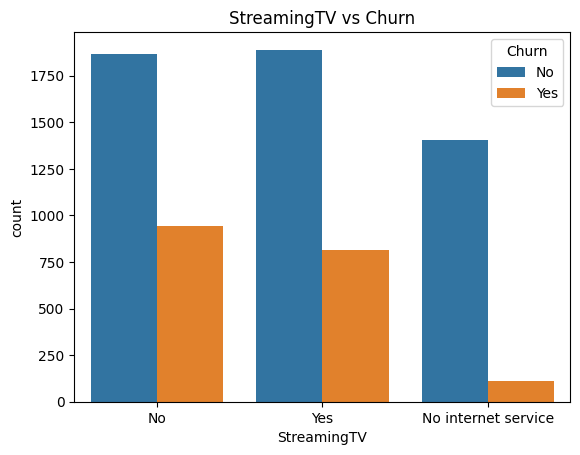

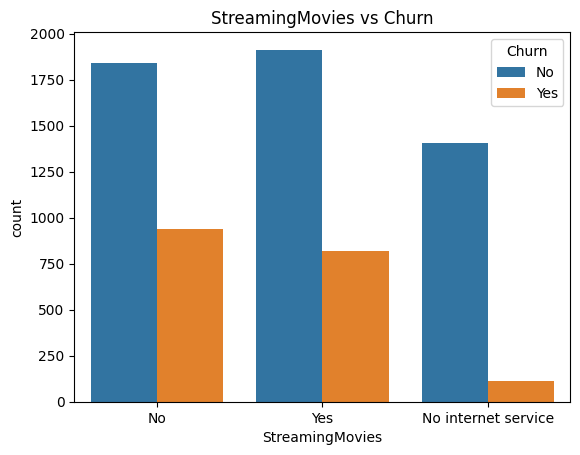

In [19]:
services = [
    'OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport',
    'StreamingTV','StreamingMovies'
]

for s in services:
    sns.countplot(x=s, hue='Churn', data=df)
    plt.title(f"{s} vs Churn")
    plt.show()

##Investigation summary

- Customers with shorter tenure tend to churn more.
- Higher monthly charges appear to be associated with increased churn.
- Service usage shows variation in churn behavior.

These observations support the creation of new features that capture customer lifecycle, service engagement, and cost burden.

##Feature Engineering

Based on exploratory analysis, new features were created to better represent customer lifecycle, service engagement, and cost burden.

In [20]:
df['CustomerStage'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['New','Early','Established','Loyal']
)

In [21]:
services = [
    'OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport',
    'StreamingTV','StreamingMovies'
]

df['ServiceCount'] = (df[services] == 'Yes').sum(axis=1)

In [22]:
df['HighMonthlyCost'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

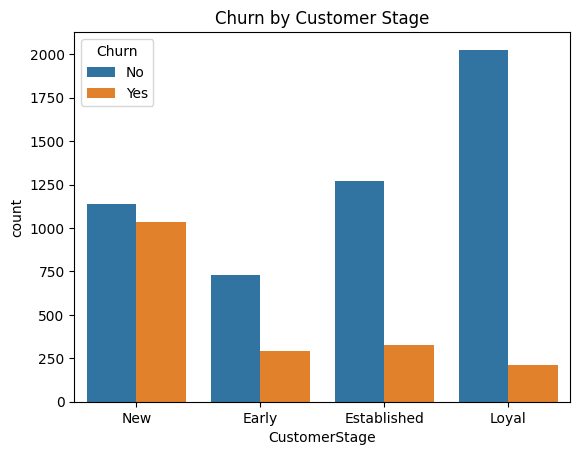

In [23]:
sns.countplot(x='CustomerStage', hue='Churn', data=df)
plt.title("Churn by Customer Stage")
plt.show()



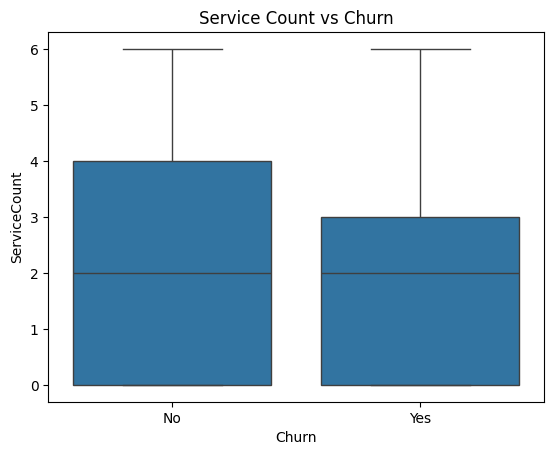

In [24]:
sns.boxplot(x='Churn', y='ServiceCount', data=df)
plt.title("Service Count vs Churn")
plt.show()



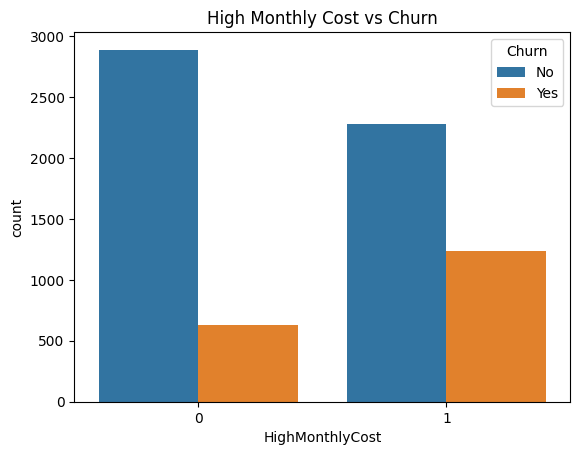

In [25]:
sns.countplot(x='HighMonthlyCost', hue='Churn', data=df)
plt.title("High Monthly Cost vs Churn")
plt.show()

##Feature Engineering Summary

Feature engineering was performed to enhance churn prediction by capturing customer lifecycle, service engagement, and cost burden patterns.  
These derived features provided additional behavioral signals that improved the model’s ability to distinguish high-risk customers

##Data Preprocessing & Encoding

In this section, we prepare the data for modeling by splitting the dataset and transforming categorical features.

In [26]:
x=df.drop('Churn',axis=1)
y = (df['Churn'] == 'Yes').astype(int)

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [28]:
numeric_features=x_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features=x_train.select_dtypes(include=['object','category']).columns.tolist()

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

numric_trasnform=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_transform=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(drop='first',handle_unknown='ignore'))
])

In [30]:
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(transformers=[
    ('num',numric_trasnform,numeric_features),
    ('cat',categorical_transform,categorical_features)
])

## Preprocessing Summary
- The dataset was split into training and testing sets.
- A preprocessing pipeline was applied to handle both numerical and categorical features.
- Numerical features were standardized.
- Categorical features were encoded using One-Hot Encoding.
- The pipeline ensures consistent transformation and prevents data leakage.

##Modeling Approach

Two modeling strategies were adopted to predict customer churn.

A Logistic Regression model was used as a baseline due to its interpretability and ability to highlight general churn patterns.

A Random Forest model was then developed and optimized using cross-validation and hyperparameter tuning to capture non-linear relationships and improve predictive performance.

In [31]:

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

LogisticRegression ROC-AUC: 0.8342621304440107
LogisticRegression PR-AUC : 0.6236339008890462

 LogisticRegression Classification Report :
               precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407



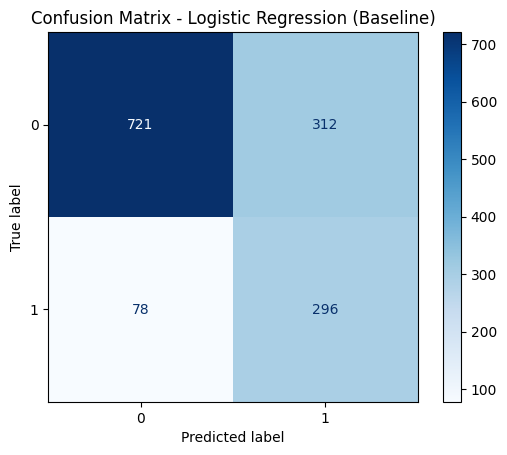

In [32]:
log_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced',random_state=42))
])

log_pipe.fit(x_train, y_train)

y_log_pred = log_pipe.predict(x_test)
y_log_proba = log_pipe.predict_proba(x_test)[:, 1]

print("LogisticRegression ROC-AUC:", roc_auc_score(y_test, y_log_proba))
print("LogisticRegression PR-AUC :", average_precision_score(y_test, y_log_proba))
print("\n LogisticRegression Classification Report :\n", classification_report(y_test, y_log_pred))

conf_matrix= confusion_matrix(y_test, y_log_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Baseline)")
plt.show()

In [33]:
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid_rf = {
    'model__n_estimators': [300, 600],
    'model__max_depth': [None, 12, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    rf_pipe,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best CV ROC-AUC:", grid_rf.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 600}
Best CV ROC-AUC: 0.8454161166762493


Best RF Test ROC-AUC: 0.8343863726956946
Best RF Test PR-AUC : 0.6330372465784764

Classification Report (Best RF):
               precision    recall  f1-score   support

           0       0.89      0.79      0.84      1033
           1       0.56      0.72      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



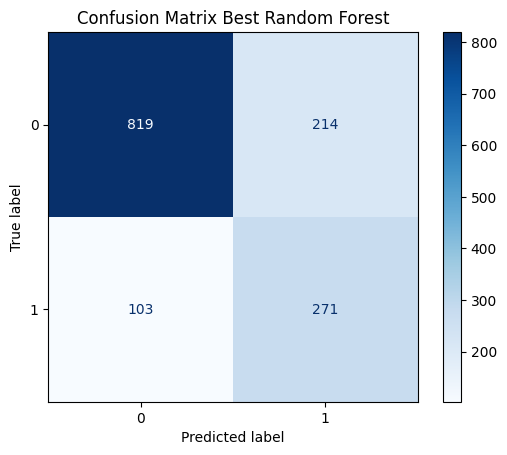

In [34]:
best_rf = grid_rf.best_estimator_

y_rf_pred = best_rf.predict(x_test)
y_rf_proba = best_rf.predict_proba(x_test)[:, 1]

print("Best RF Test ROC-AUC:", roc_auc_score(y_test, y_rf_proba))
print("Best RF Test PR-AUC :", average_precision_score(y_test, y_rf_proba))
print("\nClassification Report (Best RF):\n", classification_report(y_test, y_rf_pred))


conf_matrix= confusion_matrix(y_test, y_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix Best Random Forest")
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Random Forest (Tuned)"],
    "Accuracy": [accuracy_score(y_test, y_log_pred), accuracy_score(y_test, y_rf_pred)],
    "Precision": [precision_score(y_test, y_log_pred), precision_score(y_test, y_rf_pred)],
    "Recall": [recall_score(y_test, y_log_pred), recall_score(y_test, y_rf_pred)],
    "F1": [f1_score(y_test, y_log_pred), f1_score(y_test, y_rf_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_log_proba), roc_auc_score(y_test, y_rf_proba)],
    "PR-AUC": [average_precision_score(y_test, y_log_proba), average_precision_score(y_test, y_rf_proba)]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression (Baseline),0.722814,0.486842,0.791444,0.602851,0.834262,0.623634
1,Random Forest (Tuned),0.774698,0.558763,0.724599,0.630966,0.834386,0.633037


## Model Evaluation

Model performance was evaluated using multiple metrics including ROC-AUC, Precision–Recall curves, and confusion matrices.

Because churn datasets are typically imbalanced, evaluation focused on metrics that better capture performance on the minority class.

These metrics help assess how well the model identifies customers at risk of churn.

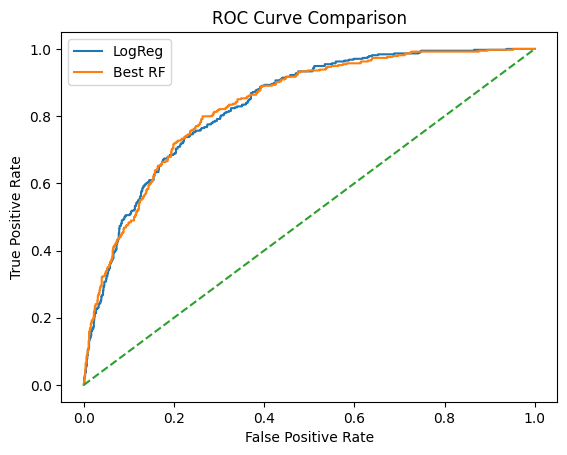

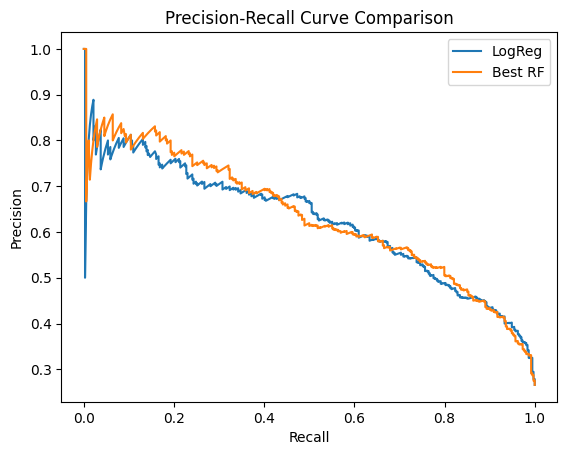

In [36]:
# ROC
fpr_l, tpr_l, _ = roc_curve(y_test, y_log_proba)
fpr_r, tpr_r, _ = roc_curve(y_test, y_rf_proba)

plt.plot(fpr_l, tpr_l, label="LogReg")
plt.plot(fpr_r, tpr_r, label="Best RF")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# PR
p_l, r_l, _ = precision_recall_curve(y_test, y_log_proba)
p_r, r_r, _ = precision_recall_curve(y_test, y_rf_proba)

plt.plot(r_l, p_l, label="LogReg")
plt.plot(r_r, p_r, label="Best RF")
plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

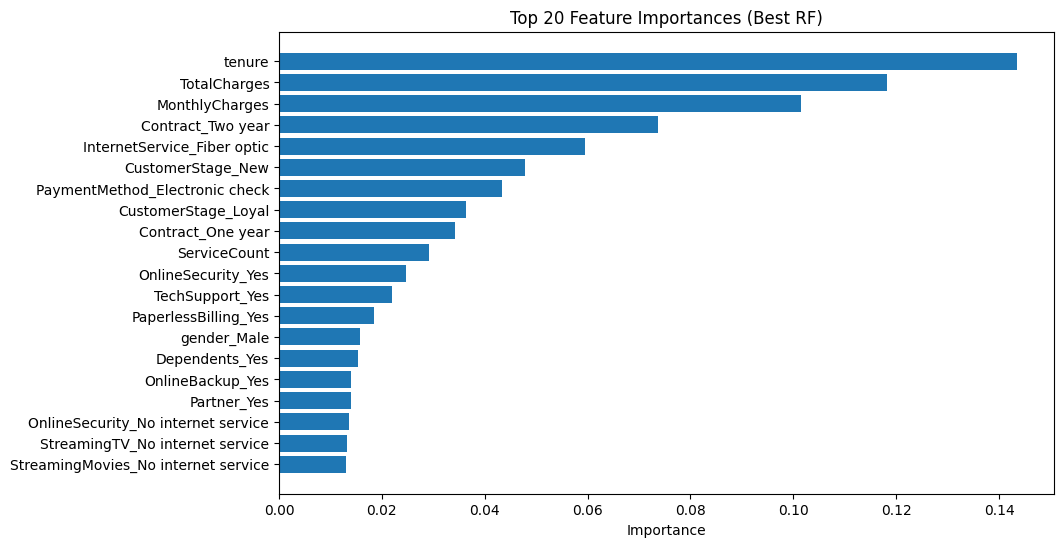

,Feature,Importance
1,tenure,0.143503
3,TotalCharges,0.118267
2,MonthlyCharges,0.101520
27,Contract_Two year,0.073638
12,InternetService_Fiber optic,0.059577
34,CustomerStage_New,0.047882
30,PaymentMethod_Electronic check,0.043273
33,CustomerStage_Loyal,0.036363
26,Contract_One year,0.034214
4,ServiceCount,0.029199


In [37]:
import numpy as np

ohe = best_rf.named_steps['preprocessor'] \
            .named_transformers_['cat'] \
            .named_steps['onehot']

cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_names])

importances = best_rf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} Feature Importances (Best RF)")
plt.xlabel("Importance")
plt.show()

top_features

## Feature Importance Insights

The importance of features for predicting customer churn shows that customer tenure is the most predictive feature, with new customers having a higher probability to churn.


The analysis also identifies billing related variables (i.e. TotalCharges, MonthlyCharges) as being important for predicting churn because customers will have an idea as to what they are paying for.



The type of contract is another important factor in predicting churn risk, where customers with longer contract terms are less likely to churn.



Finally, the service related variables (i.e. ServiceCount, Online Security, Tech Support) suggest that customers who are using multiple services are less likely to churn (due to their stronger engagement with the retailer).

## Threshold Optimization

Several thresholds were assessed in order to better own on pointless interventions.balance precision and recall rather than depending on the default classification threshold of 0.5.

This makes it possible for the model to match business objectives, like increasing churn detection or cutting d

In [38]:

thresholds = np.linspace(0.1, 0.9, 9)
rows = []

for t in thresholds:
    pred_t = (y_rf_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred_t),
        "recall": recall_score(y_test, pred_t),
        "f1": f1_score(y_test, pred_t)
    })

pd.DataFrame(rows)

,threshold,precision,recall,f1
0,0.1,0.354492,0.970588,0.519313
1,0.2,0.409624,0.933155,0.569331
2,0.3,0.457507,0.863636,0.598148
3,0.4,0.505051,0.802139,0.619835
4,0.5,0.558763,0.724599,0.630966
5,0.6,0.596730,0.585561,0.591093
6,0.7,0.657480,0.446524,0.531847
7,0.8,0.750000,0.272727,0.400000
8,0.9,0.795455,0.093583,0.167464


## Modeling Summary

Both models demonstrated strong predictive capability in distinguishing churn from non-churn customers.

The Random Forest model showed improved precision in identifying high-risk customers, making it more suitable for targeted retention strategies.

Threshold tuning further enabled alignment of model predictions with business priorities, allowing flexibility between maximizing churn detection (recall) and minimizing unnecessary interventions (precision).

Overall, the modeling approach provided both interpretable insights and operationally useful predictions to support customer retention decision-making.

## Recommendations For The Business

Churn risk is higher for customers who have shorter tenures, more expensive monthly charges, and lower usage of services.

Churn mitigation can be accomplished by implementing targeted retention strategies such as onboarding assistance, pricing incentives, and service bundles.

The model provides the ability to identify high-risk customers early, allowing the business to engage in data-based retention efforts/right strategy to retain them.

## Conclusion

In conclusion, the project aimed to create a churn prediction model to identify potential churners.

Exploratory data analysis and feature engineering were used to identify the primary factors that contribute to churn, both from a behavioral and financial perspective.  
A tuned Random Forest model was found to have strong prediction potential, which could be used to accurately identify potential churners.

This project was able to provide a solution that utilizes prediction modeling, threshold tuning, and feature engineering to address the problem of churn prediction.